In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import functools
from pathlib import Path

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches
import matplotlib.colors
import seaborn as sns
font_scale = 7
sns.set_theme(style='ticks', font_scale=font_scale, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

# Run queries

### Datasets

In [5]:
dataset_cols = """
    Dataset.id,
    time_step_count,
    time_step_count_drop_first,
    observe_every_n_time_steps,
"""

In [10]:
dataset_info = pl.DataFrame(dict(
    dataset_name=['Lorenz96', 'KuramotoSivashinsky', 'NavierStokesDim64', 'NavierStokesDim256'],
    dataset_name_latex=["Lorenz '96", 'Kuramoto-Sivashinsky (1,024 dim)', r'Navier-Stokes ($64 \times 64$)', r'Navier-Stokes ($256 \times 256$)'],
    sampling_time_step_count=[5, 5, 10, 10],
    multiple=1,
))
dataset_info

dataset_name,dataset_name_latex,sampling_time_step_count,multiple
str,str,i64,i32
"""Lorenz96""","""Lorenz '96""",5,1
"""KuramotoSivashinsky""","""Kuramoto-Sivashinsky (1,024 di…",5,1
"""NavierStokesDim64""","""Navier-Stokes ($64 \times 64$)""",10,1
"""NavierStokesDim256""","""Navier-Stokes ($256 \times 256…",10,1


##### Lorenz '96

In [316]:
dataset_name, dataset_name_latex = 'Lorenz96', "Lorenz '96"
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join Lorenz96 on Dataset.id = Lorenz96.id
    where true
    and state_dimension = 1e6
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Kuramoto-Sivashinsky

In [102]:
dataset_name, dataset_name_latex = 'KuramotoSivashinsky', 'Kuramoto-Sivashinsky'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension = 1024
    and floating_point_precision = 32
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($64 \times 64$)

In [292]:
dataset_name, dataset_name_latex = 'NavierStokesDim64', r'Navier-Stokes ($64 \times 64$)'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    join ATan on Dataset.Observe = ATan.id
    where true
    and state_dimension = 3*64*64
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
    and predicted_state_count = 20
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

##### Navier-Stokes ($256 \times 256$)

In [332]:
dataset_name, dataset_name_latex = 'NavierStokesDim256', r'Navier-Stokes ($256 \times 256$)'
dataset_rows = duckdb.sql(f"""
    select
        {dataset_cols}
    from Dataset
    join NavierStokes on Dataset.id = NavierStokes.id
    where true
    and state_dimension = 3*256*256
    and time_step_count = 6000
    and time_step_size = 1e-4
    and observe_every_n_time_steps = 100
    and use_predicted_state_perturbation = false
    and predicted_state_perturbation_std = 0.
""")
assert len(dataset_rows) == 1
dataset_multiple = 1

### Models

In [333]:
sampling_time_step_counts = (5, 10, 20, 50, 100)

In [334]:
filepaths = duckdb.sql("""
    select
        dataset_name, label, format('{}/TopK_{}_T{}.csv', dataset_name, label, sampling_time_step_count) as filepath
    from dataset_info
    cross join (
        select * as label from (values ('EnFF-OT'), ('EnFF-F2P'))
    )
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(
    dataset_name=filepaths['dataset_name'],
    label=filepaths['label'],
    filepath=filepaths.get_column('filepath'),
    exists=filepath_exists,
))
assert filepaths['exists'].any()
duckdb.sql("""
set variable hyperparameter_filepaths = (
    select list(filepath) from filepaths where exists
)
""")
topk_hyperparameters = duckdb.sql("""
    select
        filepaths.dataset_name,
        label,
        sigma_min,
        lambda,
    from read_csv(getvariable(hyperparameter_filepaths), filename=true, union_by_name=true) as csv_data
    join filepaths
    on csv_data.filename = filepaths.filepath
    where k = 1
""").pl()
hyperparameter_grid = duckdb.sql("""
    select
        label, sigma_min, lambda
    from read_csv('../sweeps/enff_sigma_min.csv') cross join read_csv('../sweeps/enff_lambda.csv') cross join (values ('EnFF-OT'), ('EnFF-F2P')) as temp(label)
""")
hyperparameters = duckdb.sql("""
    select
        topk_hyperparameters.dataset_name,
        topk_hyperparameters.label,
        hyperparameter_grid.sigma_min,
        hyperparameter_grid.lambda,
        topk_hyperparameters.sigma_min = hyperparameter_grid.sigma_min as has_optimal_sigma_min,
        topk_hyperparameters.lambda = hyperparameter_grid.lambda as has_optimal_lambda,
    from topk_hyperparameters
    join hyperparameter_grid on (
        topk_hyperparameters.label = hyperparameter_grid.label
        and (
            topk_hyperparameters.sigma_min = hyperparameter_grid.sigma_min
            or
            topk_hyperparameters.lambda = hyperparameter_grid.lambda
        )
    )
""").pl()
assert len(hyperparameters) == (
    2  # models
    * 17  # hyperparameter pairs
    * 4  # datasets
)
hyperparameters

dataset_name,label,sigma_min,lambda,has_optimal_sigma_min,has_optimal_lambda
str,str,f64,f64,bool,bool
"""NavierStokesDim256""","""EnFF-OT""",0.01,0.001,true,false
"""NavierStokesDim256""","""EnFF-OT""",0.01,0.005,true,true
"""NavierStokesDim256""","""EnFF-OT""",0.01,0.05,true,false
"""NavierStokesDim256""","""EnFF-OT""",0.01,0.1,true,false
"""NavierStokesDim256""","""EnFF-OT""",0.01,0.2,true,false
…,…,…,…,…,…
"""Lorenz96""","""EnFF-OT""",0.00001,0.05,false,true
"""Lorenz96""","""EnFF-F2P""",0.1,0.05,false,true
"""Lorenz96""","""EnFF-F2P""",0.01,0.05,false,true


##### EnFF-OT

In [344]:
label = 'EnFF-OT'
enff_ot_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        ConditionalOptimalTransport.sigma_min,
        Constant.constant as lambda,
        sampling_time_step_count,
        has_optimal_sigma_min,
        has_optimal_lambda,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    join hyperparameters on (
            hyperparameters.dataset_name = {dataset_name!r}
        and
            hyperparameters.label = {label!r}
        and
            (hyperparameters.sigma_min, hyperparameters.lambda) = (ConditionalOptimalTransport.sigma_min, Constant.constant)
    )
    where true
    and sampling_time_step_count in {sampling_time_step_counts}
    and sampler = 'EULER'
""")
enff_ot_multiple = (
    len(sampling_time_step_counts)
    * 17  # hyperparameter pairs
)
assert len(enff_ot_rows) == enff_ot_multiple

##### EnFF-F2P

In [346]:
label = 'EnFF-F2P'
enff_f2p_rows = duckdb.sql(f"""
    select distinct
        Model.id,
        {label!r} as label,
        PreviousPosteriorToPredictive.sigma_min,
        Constant.constant as lambda,
        sampling_time_step_count,
        has_optimal_sigma_min,
        has_optimal_lambda,
    from Model
    join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id
    join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id
    join Local on FlowMatchingMarginal.EnergyGuidance = Local.id
    join Constant on Local.Schedule = Constant.id
    join hyperparameters on (
            hyperparameters.dataset_name = {dataset_name!r}
        and
            hyperparameters.label = {label!r}
        and
            (hyperparameters.sigma_min, hyperparameters.lambda) = (PreviousPosteriorToPredictive.sigma_min, Constant.constant)
    )
    where true
    and sampling_time_step_count in {sampling_time_step_counts}
""")
enff_f2p_multiple = (
    len(sampling_time_step_counts)
    * 17  # hyperparameter pairs
)
assert len(enff_f2p_rows) == enff_f2p_multiple

### General

In [347]:
rows = duckdb.sql(f"""
    select
        alt_id,
        model_rows.*,
        dataset_rows.*,
        rng_seed,
    from Conf
    join dataset_rows on Conf.Dataset = dataset_rows.id
    join (
        select * from enff_ot_rows
        union
        select * from enff_f2p_rows
    ) as model_rows on Conf.Model = model_rows.id
    where true
    and rng_seed in (462133975, 979497033, 97616566, 715319214, 19704671)
""")
rng_seed_multiple = 5
model_multiple = 2
hyperparameter_pair_count = 17
multiple = rng_seed_multiple * dataset_multiple * len(sampling_time_step_counts) * model_multiple * hyperparameter_pair_count
assert len(rows) == multiple, f'{len(rows) = } != {multiple}'

In [348]:
filepaths = duckdb.sql("""
select alt_id, format('~/out/dafm/runs/{}/dataset_metrics.csv', alt_id) as filepath from rows
""").pl()
filepath_exists = []
for f in filepaths.get_column('filepath'):
    f = Path(f).expanduser()
    exists = f.exists()
    if not exists:
        print(f"File path does not exist: '{f}'")
    filepath_exists.append(exists)
filepaths = pl.DataFrame(dict(alt_id=filepaths['alt_id'], filepath=filepaths.get_column('filepath'), exists=filepath_exists))
assert filepaths['exists'].any()
duckdb.sql("""
set variable dataset_metrics_filepaths = (
    select list(filepath) from filepaths where exists
)
""")

##### RMSE and CRPS    

In [349]:
observation_steps_back = 50
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
    and step > time_step_count - observe_every_n_time_steps * {observation_steps_back}
""")
logged_metrics.show(max_width=100)

┌──────────┬───────┬──────────┬───┬────────────────────┬────────────────────┬──────────────────────┐
│  alt_id  │  id   │  label   │ … │       time_s       │        crps        │         rmse         │
│ varchar  │ int64 │ varchar  │   │       double       │       double       │        double        │
├──────────┼───────┼──────────┼───┼────────────────────┼────────────────────┼──────────────────────┤
│ fokkgp36 │  1511 │ EnFF-OT  │ … │ 0.9581491010000036 │ 18.491676330566406 │ 0.046261463314294815 │
│ fokkgp36 │  1511 │ EnFF-OT  │ … │ 0.9544193439999731 │  17.97986602783203 │  0.04555048793554306 │
│ fokkgp36 │  1511 │ EnFF-OT  │ … │ 0.9689998599999967 │  17.73209571838379 │  0.04550297185778618 │
│ fokkgp36 │  1511 │ EnFF-OT  │ … │ 0.9718748500000061 │  16.06861686706543 │ 0.040554244071245193 │
│ fokkgp36 │  1511 │ EnFF-OT  │ … │        0.945945494 │ 15.117349624633789 │ 0.037803325802087784 │
│ fokkgp36 │  1511 │ EnFF-OT  │ … │  1.010241776999976 │ 14.993549346923828 │  0.0381572172

##### Time (seconds)

In [299]:
observation_steps_back = None
logged_metrics = duckdb.sql(f"""
    select rows.*, logs.*,
    from (
        select split(filename, '/')[-2] as alt_id, step, time_s, crps, rmse,
        from read_csv(getvariable(dataset_metrics_filepaths), filename=true, union_by_name=true)
    ) as logs
    join rows on rows.alt_id = logs.alt_id
    where true
    and (logs.step - time_step_count_drop_first - 1) % observe_every_n_time_steps == 0 -- include only analysis time steps
""")
logged_metrics.show(max_width=100)

┌──────────┬───────┬──────────┬───┬────────────────────┬─────────────────────┐
│  alt_id  │  id   │  label   │ … │        crps        │        rmse         │
│ varchar  │ int64 │ varchar  │   │       double       │       double        │
├──────────┼───────┼──────────┼───┼────────────────────┼─────────────────────┤
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 388.70440673828125 │  2.4409096240997314 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 33.598548889160156 │  0.3260820508003235 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 20.621931076049805 │  0.2278132289648056 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 15.692276000976562 │ 0.17686277627944946 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 12.386077880859375 │  0.1371280550956726 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │ 10.543865203857422 │ 0.11933790147304535 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │  9.588968276977539 │ 0.11289378255605698 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │  8.888164520263672 │ 0.10766009986400604 │
│ zjrj4w9j │   894 │ EnFF-F2P │ … │  9.1111545562744

In [350]:
if observation_steps_back is None:
    observation_steps_back = duckdb.sql(f"""
        select
            count(*) as observation_step_count,
        from logged_metrics
        group by alt_id
        order by observation_step_count desc
        limit 1
    """).fetchall()[0][0]
failed_before_finish = duckdb.sql(f"""
    select
        alt_id,
        count(*) as observation_step_count,
    from logged_metrics
    group by alt_id
    having observation_step_count < {observation_steps_back}
""")
failed_before_finish
# assert len(logged_metrics) > 0 and len(failed_before_finish) == 0, failed_before_finish

┌──────────┬────────────────────────┐
│  alt_id  │ observation_step_count │
│ varchar  │         int64          │
├──────────┼────────────────────────┤
│ b74tk20k │                     49 │
│ uq2n527n │                     32 │
│ rr7d8bi3 │                     18 │
└──────────┴────────────────────────┘

In [351]:
logged_metrics = duckdb.sql("""
    select *
    from logged_metrics
    where alt_id not in (select alt_id from failed_before_finish)
""")

In [352]:
duckdb.sql("""
    select
        label, sampling_time_step_count, count(*) as 'Num. Failed',
    from rows
    where
        alt_id not in (
            select alt_id from logged_metrics
        )
    group by label, sampling_time_step_count
    order by label desc, sampling_time_step_count
""")

┌──────────┬──────────────────────────┬─────────────┐
│  label   │ sampling_time_step_count │ Num. Failed │
│ varchar  │          int64           │    int64    │
├──────────┼──────────────────────────┼─────────────┤
│ EnFF-OT  │                        5 │          35 │
│ EnFF-OT  │                       10 │           3 │
│ EnFF-F2P │                        5 │          35 │
│ EnFF-F2P │                       10 │          14 │
└──────────┴──────────────────────────┴─────────────┘

In [353]:
group_by = """
    -- alt_id,
    -- rng_seed,
    label,
    sampling_time_step_count,
    has_optimal_sigma_min,
    has_optimal_lambda,
    sigma_min,
    lambda,
"""
logged_metrics_means = duckdb.sql(f"""
    select
        {group_by}
        mean(time_s) as time_s_mean,
        mean(rmse) as rmse,
        mean(crps) as crps,
    from logged_metrics
    group by
        {group_by}
""")
logged_metrics_means.show(max_width=100)

┌──────────┬──────────────────────┬───┬──────────────────────┬────────────────────┐
│  label   │ sampling_time_step…  │ … │         rmse         │        crps        │
│ varchar  │        int64         │   │        double        │       double       │
├──────────┼──────────────────────┼───┼──────────────────────┼────────────────────┤
│ EnFF-OT  │                   10 │ … │ 0.033381532352417705 │ 14.506136905670166 │
│ EnFF-OT  │                   10 │ … │  0.05740663161873817 │  23.79160108947754 │
│ EnFF-OT  │                   10 │ … │  0.16460742419958116 │  71.44548361206054 │
│ EnFF-F2P │                  100 │ … │   0.1613406538963318 │  71.53448095703125 │
│ EnFF-OT  │                    5 │ … │   0.2519848538637161 │  109.3829538269043 │
│ EnFF-OT  │                   10 │ … │ 0.043340036362409594 │  17.92015106201172 │
│ EnFF-F2P │                  100 │ … │  0.13300026589632033 │  58.92687887573242 │
│ EnFF-F2P │                  100 │ … │   0.1621733444929123 │  71.904321212

/home/ttransue/GitHub/Data-Assimilation-Flow-Matching/.venv/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 15.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ttransue/GitHub/Data-Assimilation-Flow-Matching/.venv/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 46.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ttransue/GitHub/Data-Assimilation-Flow-Matching/.venv/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 23.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/ttransue/GitHub/Data-Assimilation-Flow-Matching/.venv/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 30.8% of the points cannot be placed; you may want to decre

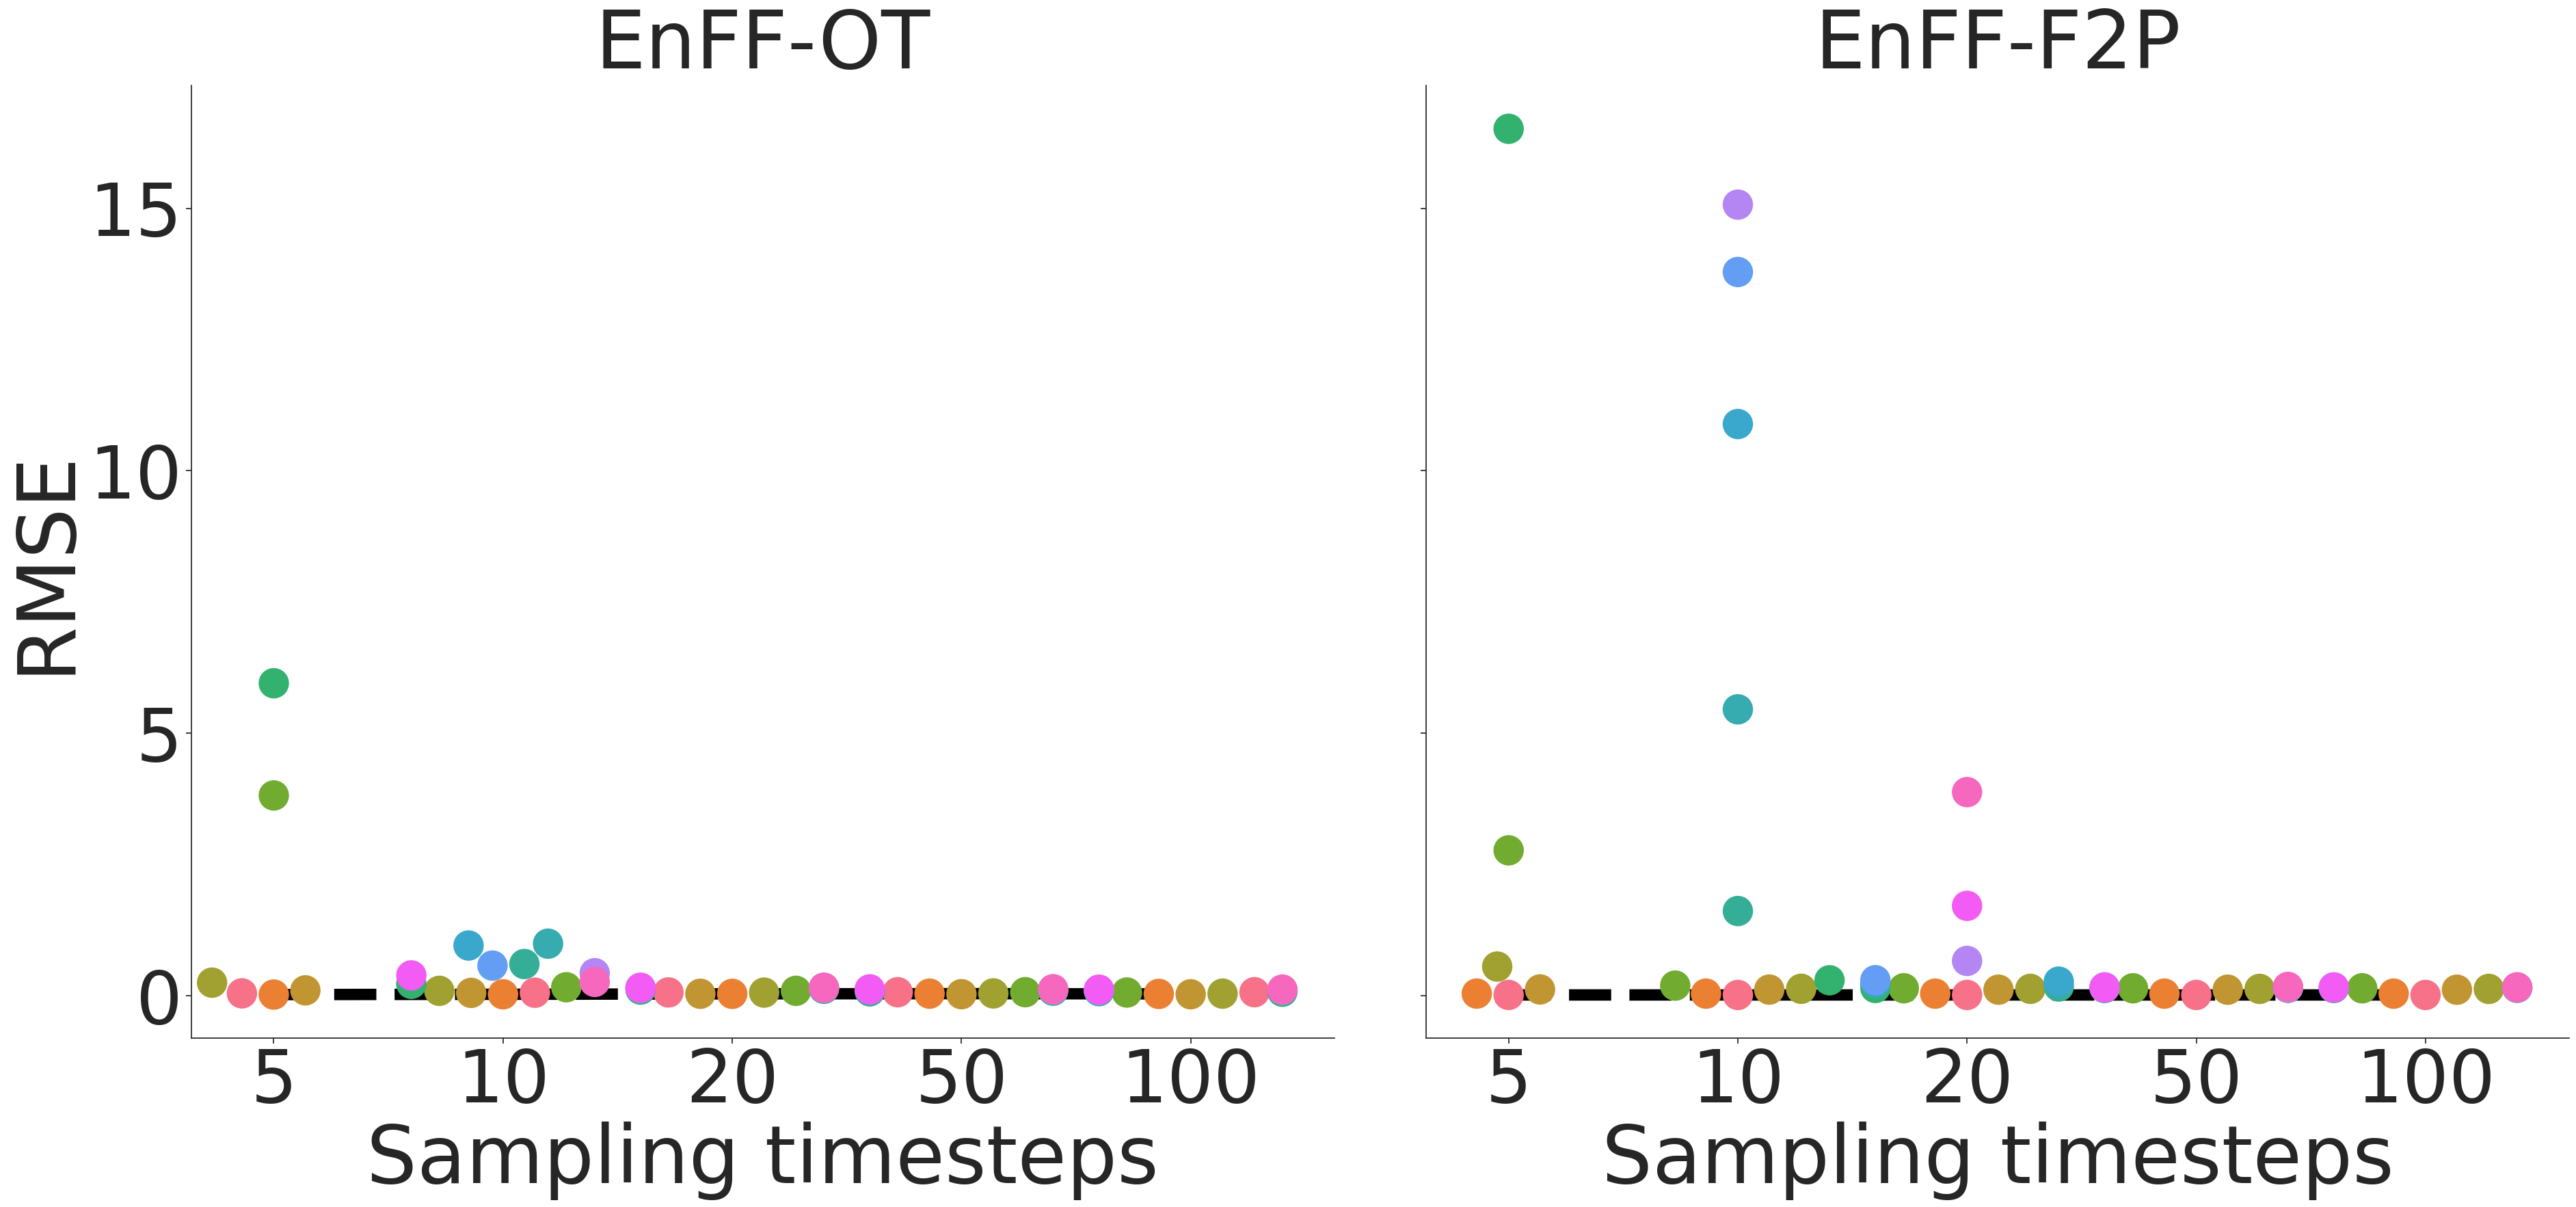

In [356]:
cols = """
    label,
    sampling_time_step_count,
    cast(sigma_min as varchar) as sigma_min,
    cast(lambda as varchar) as lambda,
    rmse,
    crps,
"""
optimal_var, hue = 'sigma_min', 'lambda'
# optimal_var, hue = 'lambda', 'sigma_min'
plot_data = duckdb.sql(f"""
    select
        label,
        sampling_time_step_count,
        cast(sigma_min as varchar) as sigma_min,
        cast(lambda as varchar) as lambda,
        rmse,
        crps,
    from logged_metrics_means
    where has_optimal_{optimal_var}
    order by {hue}
""").df()
hue_order = plot_data[hue].unique()
y = 'rmse'
plot_metric = (
    sns.catplot(
        kind='swarm',
        data=plot_data,
        x='sampling_time_step_count',
        y=y,
        col='label',
        col_order=['EnFF-OT', 'EnFF-F2P'],
        hue=hue,
        legend=False,
        # s=512,
        s=1024,
        height=20,
    )
    .set(
        xlabel='Sampling timesteps',
        ylabel=y.upper(),
    )
    .set_titles('{col_name}')
)
for (row, col, _), data in plot_metric.facet_data():
    ax = plot_metric.axes[row, col]
    label = plot_metric.col_names[col]
    y_values = duckdb.sql(f"""
        select
            {y}
        from logged_metrics_means
        where has_optimal_{optimal_var} and has_optimal_{hue}
        and label = {label!r}
        order by sampling_time_step_count
    """).fetchnumpy()[y]
    ax.plot(range(y_values.shape[0]), y_values, c='black', lw=12, ls='--', marker='_')

In [355]:
plot_metric.savefig(f'{y.upper()}.vary_{hue}.pdf', pad_inches=.06)
dataset_name, observation_steps_back

('NavierStokesDim256', 50)

In [151]:
dataset_name

'KuramotoSivashinsky'

In [142]:
temp = plot_data.filter(sampling_time_step_count=10, rng_seed=97616566).select('alt_id', 'label')
duckdb.sql("""select * from temp""")

┌──────────┬──────────┐
│  alt_id  │  label   │
│ varchar  │ varchar  │
├──────────┼──────────┤
│ w45lmnof │ EnFF-F2P │
│ 5m61kobi │ EnFF-OT  │
│ hk71m4om │ EnSF     │
└──────────┴──────────┘